mkdir -p failed for path /home/grace/.config/matplotlib: [Errno 20] Not a directory: '/home/grace/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-6giio534 because there was an issue with the default path (/home/grace/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


[256, 256, 257, 258, 258, 259, 260, 260, 261, 262, 262, 263, 264, 264, 265, 266, 266, 267, 268, 268, 269, 269, 270, 271, 271, 272, 273, 273, 274, 275, 275, 276, 277, 277, 278, 279, 279, 280, 281, 281]
[560, 559, 559, 559, 558, 558, 558, 557, 557, 557, 556, 556, 556, 555, 555, 555, 554, 554, 554, 553, 553, 552, 552, 552, 551, 551, 551, 550, 550, 550, 549, 549, 549, 548, 548, 548, 547, 547, 547, 546]
[np.float32(-67.42213), np.float32(-66.75706), np.float32(-66.14751), np.float32(-65.52425), np.float32(-64.86981), np.float32(-64.2316), np.float32(-63.579323), np.float32(-62.938057), np.float32(-62.27154), np.float32(-61.590702), np.float32(-60.965183), np.float32(-60.270977), np.float32(-59.562286), np.float32(-58.955105), np.float32(-58.23409), np.float32(-57.49853), np.float32(-56.912254), np.float32(-56.16556), np.float32(-55.404404), np.float32(-54.841515), np.float32(-54.070553), np.float32(-53.527893), np.float32(-52.748184), np.float32(-51.9546), np.float32(-51.43873), np.float32(

/tmp/ipykernel_824876/1694438361.py:53: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  nav_lon = np.array(mf.variables['nav_lon'])
/tmp/ipykernel_824876/1694438361.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  nav_lat = np.array(mf.variables['nav_lat'])
/mnt/storage6/grace/anaconda/envs/anha4nwcorner/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(

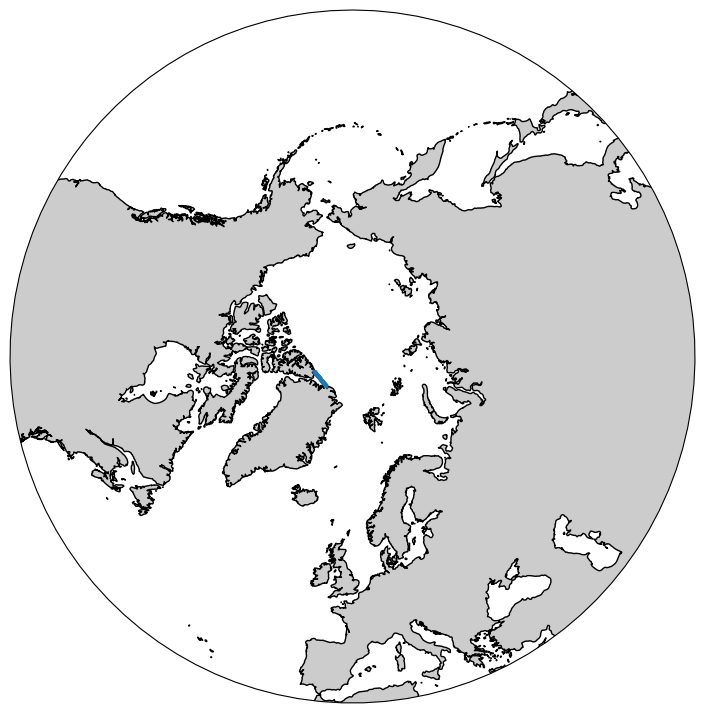

In [1]:
"""
Author: Tahya Weiss-Gibbons (adapted by Grace Kirkpatrick)
Map a transport section on map of the domain
Need the i,j start and end point
Uses same line calculation as transport script
"""
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.feature as feature

#first calculate the section data
x1 = 256
x2 = 282
y1 = 560
y2 = 546

ii = []
jj = []

dx = x2-x1
dy = y2-y1
yi = 1

if dy < 0:
    yi = -1
    dy = -dy

D = (2*dy) - dx
y = y1
slope = []

for x in range(x1,x2):
    ii.append(x)
    jj.append(y)
    if D > 0:
        y = y +yi
        D = D + (2*(dy-dx))
        ii.append(x)
        jj.append(y)
    else:
        D = D + 2*dy

print(ii)
print(jj)

#next read in the mesh grid file 
mask_file = '/mnt/storage6/grace/data/ANHA4_mesh_mask.nc'
mf = nc.Dataset(mask_file)

nav_lon = np.array(mf.variables['nav_lon'])
nav_lat = np.array(mf.variables['nav_lat'])

mf.close()

#get the grid coordinates on map coordinates
ln = []
lt = []
for k in range(len(ii)):
    ln.append(nav_lon[jj[k], ii[k]])
    lt.append(nav_lat[jj[k], ii[k]])

print(ln)
print(lt)

#now we can plot the line on a map 
#north pole stero projection
land_50m = feature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='black', facecolor='gray', linewidth=0.5)
projection=ccrs.NorthPolarStereo()

fig = plt.figure(figsize=(10, 9))
ax = plt.subplot(1, 1, 1, projection=projection)

ax.set_extent([-280, 80, 80, 35], crs=ccrs.PlateCarree())
ax.add_feature(land_50m, color=[0.8, 0.8, 0.8])
ax.coastlines(resolution='50m')

# Compute a circle in axes coordinates, which we can use as a boundary
# for the map. We can pan/zoom as much as we like - the boundary will be
# permanently circular.
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

ax.plot(ln, lt, linewidth=3.0, transform=ccrs.PlateCarree())
#plt.show()
plt.savefig('greenland_north_section.png')